link do Dashbordu ponizej:

https://public.tableau.com/app/profile/maciej.klysiak/viz/portfolio1_17858847075260/Dashboard1?publish=yes

In [ ]:
# PL: Import niezbędnych bibliotek do analizy danych
# EN: Import necessary libraries for data analysis
import pandas as pd

# PL: Połączenie środowiska Google Colab z Dyskiem Google w celu uzyskania dostępu do plików
# EN: Mount Google Drive in the Google Colab environment to access files
from google.colab import drive

drive.mount("/content/drive")

# PL: Zdefiniowanie ścieżki dostępu do pliku CSV na Dysku Google
# EN: Define the file path to the CSV file on Google Drive
sciezka_do_pliku = (
    "/content/drive/MyDrive/portfolio 1/porfolio_analiza_sprzedazy.csv"
)

# PL:  Wczytanie danych z pliku CSV do obiektu DataFrame biblioteki Pandas
# EN:  Load data from the CSV file into a Pandas DataFrame object
df = pd.read_csv(sciezka_do_pliku)

# PL: Wyświetlenie pierwszych 5 wierszy tabeli w celu zweryfikowania, czy dane zostały wczytane poprawnie
# EN: Display the first 5 rows of the table to verify if the data has been loaded correctly
df.head()

Mounted at /content/drive


,order_date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source_information,traffic_channel,registered_user_id,is_email_confirmed,is_newsletter_subscribed,product_category,product_name,price,short_product_description
0,2021-01-31,270887945,Americas,United States,desktop,Chrome,Safari,Web,en-us,cpc / <Other>,Organic Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-31,4958826563,Asia,India,mobile,Safari,iPhone,iOS,de,(data deleted) / (data deleted),Undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-31,6336117447,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none) / (direct),Direct,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-31,464560636,Americas,United States,desktop,Edge,Edge,Web,en-us,organic / (organic),Organic Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-31,5756982967,Europe,Ukraine,desktop,Firefox,Firefox,Windows,en-us,referral / (referral),Social Search,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df

In [ ]:
# PL: Konwersja kolumny z datą zamówienia na właściwy typ datetime
# EN: Convert the order date column to a proper datetime type
df["order_date"] = pd.to_datetime(df["order_date"])

# PL: Wyświetlenie podstawowych statystyk dotyczących rozmiaru ramki danych, sesji i zakresu dat
# EN: Display basic statistics regarding dataframe size, sessions, and date range
print("--- PODSTAWOWE INFORMACJE ---")
print(f"Całkowita liczba kolumn: {df.shape[1]}")
print(f"Liczba unikalnych sesji: {df['session_id'].nunique()}")
print(
    f"Objęty okres: od {df['order_date'].min().date()} do {df['order_date'].max().date()}\n"
)

# PL: Analiza typów danych w kolumnach
# EN: Analyze column data types
print("--- TYPY KOLUMN ---")

# PL: Wyodrębnienie i zliczenie kolumn numerycznych
# EN: Identify and count numerical columns
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(f"Liczba kolumn numerycznych: {len(num_cols)} -> {num_cols}")

# PL: Wyodrębnienie i zliczenie kolumn zawierających daty i czas
# EN: Identify and count datetime columns
date_cols = df.select_dtypes(include=["datetime"]).columns.tolist()
print(f"Liczba kolumn daty i godziny: {len(date_cols)} -> {date_cols}")

# PL: Wyodrębnienie i zliczenie kolumn kategorycznych
# EN: Identify and count categorical
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Liczba kolumn kategorycznych: {len(cat_cols)} -> {cat_cols}\n")

# PL: Analiza brakujących wartości (NULL/NaN) w całym zbiorze danych
# EN: Analysis of missing values (NULL/NaN) across the dataset
print("--- BRAKUJĄCE WARTOŚCI (NULL/NaN) ---")

# PL: Obliczenie liczby braków dla każdej kolumny i posortowanie wyników malejąco
# EN: Calculate the count of missing values per column and sort in descending order
missing_values = df.isnull().sum().sort_values(ascending=False)

# PL: Filtrowanie wyników
# EN: Filter the results
missing_values = missing_values[missing_values > 0]
print(missing_values)

--- PODSTAWOWE INFORMACJE ---
Całkowita liczba kolumn: 18
Liczba unikalnych sesji: 349545
Objęty okres: od 2020-11-01 do 2021-01-31

--- TYPY KOLUMN ---
Liczba kolumn numerycznych: 5 -> ['session_id', 'registered_user_id', 'is_email_confirmed', 'is_newsletter_subscribed', 'price']
Liczba kolumn daty i godziny: 1 -> ['order_date']
Liczba kolumn kategorycznych: 12 -> ['continent', 'country', 'device', 'browser', 'device_model_name', 'operating_system', 'browser_language', 'traffic_source_information', 'traffic_channel', 'product_category', 'product_name', 'short_product_description']

--- BRAKUJĄCE WARTOŚCI (NULL/NaN) ---
is_newsletter_subscribed     321600
is_email_confirmed           321600
registered_user_id           321600
short_product_description    316007
product_name                 316007
product_category             316007
price                        316007
browser_language             114266
dtype: int64


In [ ]:
# PL: Usunięcie wierszy, gdzie kontynent nie jest określony | EN: Remove rows where the continent is '(not set)'
df = df[df['continent'] != '(not set)']

Najwięcej braków w kolumnach profilu użytkownika (registered_user_id, is_email_confirmed, is_newsletter_subscribed): Wynika to z faktu, że większość ruchu w sklepie e-commerce to użytkownicy niezarejestrowani (goście). Zgodnie z założeniami biznesowymi zachowano ich w analizie używając połączeń typu LEFT JOIN.

Braki w kolumnach produktowych (product_category, product_name, price, short_product_description): Wynikają one z tego, że zapisano wszystkie sesje. Znaczna część sesji to wyłącznie przeglądanie strony, które nie kończy się dodaniem produktu do koszyka i zapisem w tabeli order.

--- TOP 3 KONTYNENTY (WEDŁUG PRZYCHODU) ---


,continent,przychod,liczba_zamowien
1,Americas,17665280.0,18553
2,Asia,7601298.3,7950
3,Europe,5934624.2,6261



--- TOP 5 KRAJÓW (WEDŁUG PRZYCHODU) ---


,country,przychod,liczba_zamowien
104,United States,13943553.9,14673
43,India,2809762.0,3029
18,Canada,2437921.0,2560
103,United Kingdom,938317.9,1029
33,France,710692.8,678


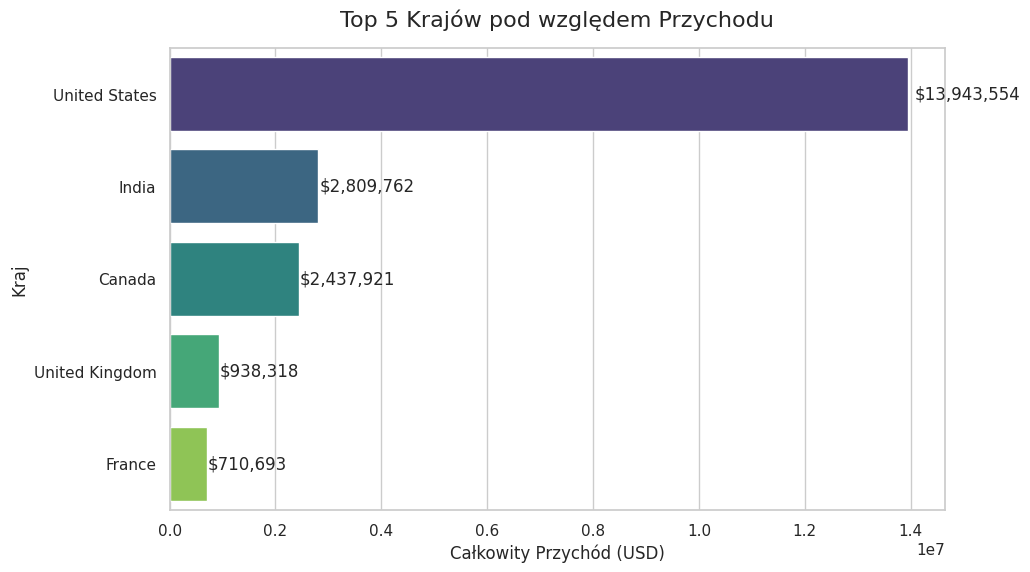

In [ ]:
# PL: Import bibliotek do tworzenia statycznych wizualizacji
# EN: Import libraries for static data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# PL: Grupowanie danych po kontynencie: obliczenie całkowitego przychodu (suma) oraz wolumenu zamówień
# EN: Group by continent: calculate total revenue (sum) and order volume
kontynenty_stat = (
    df.groupby("continent")
    .agg(przychod=("price", "sum"), liczba_zamowien=("price", "count"))
    .reset_index()
)

# PL: Sortowanie kontynentów według najwyższego przychodu i wyodrębnienie Top 3 rynków
# EN: Sort continents by revenue in descending order and extract the Top 3 markets
top3_kontynenty = kontynenty_stat.sort_values(
    by="przychod", ascending=False
).head(3)

# PL: Wyświetlenie wyników w sformatowanej tabeli
# EN: Display results in a formatted table
print("--- TOP 3 KONTYNENTY (WEDŁUG PRZYCHODU) ---")
display(top3_kontynenty)

# PL: Grupowanie danych po kraju w celu wyliczenia przychodu i liczby zamówień dla każdej lokalizacji
# EN: Group data by country to calculate revenue and transaction count for each location
kraje_stat = (
    df.groupby("country")
    .agg(przychod=("price", "sum"), liczba_zamowien=("price", "count"))
    .reset_index()
)

# PL: Sortowanie krajów według wygenerowanego przychodu i wybranie 5 najlepszych rynków (Top 5)
# EN: Sort countries by generated revenue and select the Top 5 markets
top5_kraje = kraje_stat.sort_values(by="przychod", ascending=False).head(5)

print("\n--- TOP 5 KRAJÓW (WEDŁUG PRZYCHODU) ---")
display(top5_kraje)

# PL: Zdefiniowanie wymiarów wykresu
# EN: Defining a plot dimension
plt.figure(figsize=(10, 6))

# PL: Generowanie poziomego wykresu słupkowego dla Top 5 krajów
# EN: Generate a horizontal bar plot for the Top 5 countries
wykres = sns.barplot(
    data=top5_kraje,
    x="przychod",
    y="country",
    hue="country",
    palette="viridis",
    legend=False,
)

# PL: Dodanie tytułu wykresu oraz czytelnych etykiet dla obu osi
# EN: Add a clear chart title and descriptive labels for both axes
plt.title("Top 5 Krajów pod względem Przychodu", fontsize=16, pad=15)
plt.xlabel("Całkowity Przychód (USD)", fontsize=12)
plt.ylabel("Kraj", fontsize=12)

# PL: Pętla nakładająca wartości liczbowe bezpośrednio na końcach słupków
# EN: Loop to add data labels directly at the end of each bar
for p in wykres.patches:
    szerokosc = p.get_width()
    # PL: Umieszczenie sformatowanego tekstu
    # EN: Place formatted text
    plt.text(
        szerokosc + (szerokosc * 0.01),
        p.get_y() + p.get_height() / 2,
        f"${szerokosc:,.0f}",
        ha="left",
        va="center",
    )

# PL: Wyświetlenie gotowej wizualizacji
# EN: Render and display the final visualization
plt.show()

In [ ]:
# PL: Filtrowanie danych - usunięcie wierszy z brakami w kolumnie kategorii lub ceny
# EN: Filter the dataset - drop rows with missing values in product category or price
df_sprzedaz = df.dropna(subset=["product_category", "price"])

# PL: Grupowanie danych według kategorii produktów i obliczenie całkowitego przychodu
# EN: Group the data by product category and calculate the total revenue
top_10_kategorii = (
    df_sprzedaz.groupby("product_category")["price"].sum().reset_index()
)

# PL: Sortowanie tabeli malejąco według przychodu i wybór najlepszych kategorii
# EN: Sort the table in descending order of revenue and extract the top categories
top_10_kategorii = top_10_kategorii.sort_values(
    by="price", ascending=False
).head(10)

# PL: Wyświetlenie końcowego rankingu Top 10 kategorii
# EN: Display the final Top 10 categories ranking
print("--- TOP 10 KATEGORII POD WZGLĘDEM PRZYCHODU ---")
print(top_10_kategorii)

--- TOP 10 KATEGORII POD WZGLĘDEM PRZYCHODU ---
                    product_category      price
12                 Sofas & armchairs  8364909.5
5                             Chairs  6130617.8
1                               Beds  4910160.0
2         Bookcases & shelving units  3638221.1
3               Cabinets & cupboards  2331372.5
9                  Outdoor furniture  2139090.8
13                    Tables & desks  1782311.5
6   Chests of drawers & drawer units   904552.5
0                      Bar furniture   735503.0
7               Children's furniture   467579.0


Analizujemy dane dla najlepszego kraju: United States

--- TOP 10 KATEGORII GLOBALNIE ---


,product_category,przychod
12,Sofas & armchairs,8364909.5
5,Chairs,6130617.8
1,Beds,4910160.0
2,Bookcases & shelving units,3638221.1
3,Cabinets & cupboards,2331372.5
9,Outdoor furniture,2139090.8
13,Tables & desks,1782311.5
6,Chests of drawers & drawer units,904552.5
0,Bar furniture,735503.0
7,Children's furniture,467579.0



--- TOP 10 KATEGORII W KRAJU: UNITED STATES ---


,product_category,przychod
12,Sofas & armchairs,3707144.5
5,Chairs,2619773.8
1,Beds,2213058.0
2,Bookcases & shelving units,1567606.9
3,Cabinets & cupboards,994545.5
9,Outdoor furniture,929245.2
13,Tables & desks,777865.0
6,Chests of drawers & drawer units,382388.0
0,Bar furniture,330805.0
7,Children's furniture,207575.0


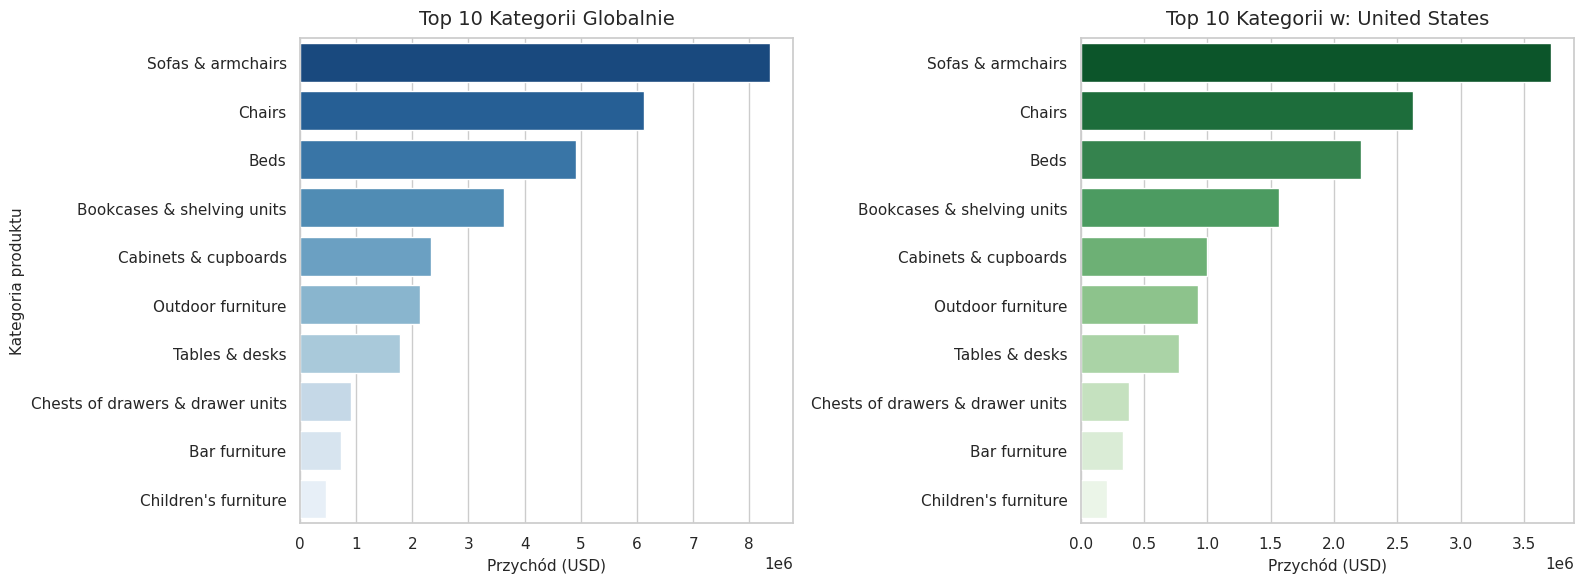

In [ ]:
# PL: Wybór najlepszego kraju na podstawie przychodów
# EN: Select the top-performing country based on revenue
najlepszy_kraj = top5_kraje.iloc[0]['country']
print(f"Analizujemy dane dla najlepszego kraju: {najlepszy_kraj}\n")

# PL: Usunięcie wierszy bez przypisanej kategorii produktu
# EN: Remove rows without a product category
df_zakupy = df.dropna(subset=['product_category'])

# PL: Obliczanie Top 10 kategorii globalnie
# EN: Calculate Top 10 categories globally
top10_globalnie = df_zakupy.groupby('product_category').agg(
    przychod=('price', 'sum')
).reset_index().sort_values(by='przychod', ascending=False).head(10)

print("--- TOP 10 KATEGORII GLOBALNIE ---")
display(top10_globalnie)

# PL: Obliczanie Top 10 kategorii w najlepszym kraju
# EN: Calculate Top 10 categories in the top country
top10_kraj = df_zakupy[df_zakupy['country'] == najlepszy_kraj].groupby('product_category').agg(
    przychod=('price', 'sum')
).reset_index().sort_values(by='przychod', ascending=False).head(10)

print(f"\n--- TOP 10 KATEGORII W KRAJU: {najlepszy_kraj.upper()} ---")
display(top10_kraj)

# PL: Tworzenie obszaru roboczego z dwoma wykresami
# EN: Create a workspace with two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PL: Wykres globalny
# EN: Global chart
sns.barplot(
    data=top10_globalnie,
    x='przychod',
    y='product_category',
    ax=axes[0],
    palette='Blues_r',
    hue='product_category',
    legend=False
)
axes[0].set_title('Top 10 Kategorii Globalnie', fontsize=14, pad=10)
axes[0].set_xlabel('Przychód (USD)', fontsize=11)
axes[0].set_ylabel('Kategoria produktu', fontsize=11)

# PL: Wykres dla najlepszego kraju
# EN: Chart for the top country
sns.barplot(
    data=top10_kraj,
    x='przychod',
    y='product_category',
    ax=axes[1],
    palette='Greens_r',
    hue='product_category',
    legend=False
)
axes[1].set_title(f'Top 10 Kategorii w: {najlepszy_kraj}', fontsize=14, pad=10)
axes[1].set_xlabel('Przychód (USD)', fontsize=11)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

--- UDZIAŁ URZĄDZEŃ W CAŁKOWITEJ SPRZEDAŻY ---


,device,price,pct
0,desktop,18812395.6,58.977346
1,mobile,12361871.8,38.754788
2,tablet,723396.3,2.267866



--- TOP 5 MODELI MOBILNYCH (UDZIAŁ W SPRZEDAŻY) ---


,device_model_name,price,pct
5,iPhone,6407286.3,20.087008
0,<Other>,5726209.6,17.951815
3,Pixel 4 XL,118287.7,0.370835
2,Pixel 3,109148.2,0.342182
4,Safari,595.0,0.001865


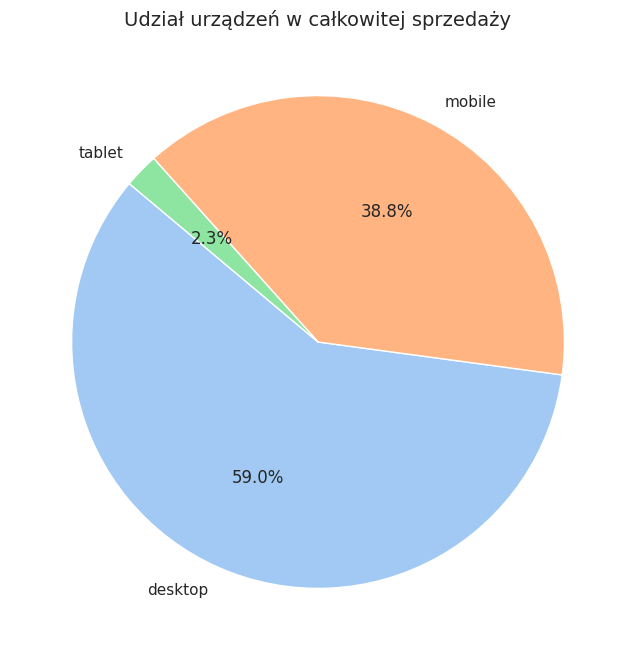

In [ ]:
# PL: Obliczanie całkowitej sprzedaży
# EN: Calculate total sales
total_sales = df['price'].sum()

# PL: Analiza wg typu urządzenia (device)
# EN: Analysis by device type
device_sales = df.groupby('device')['price'].sum().reset_index()
device_sales['pct'] = (device_sales['price'] / total_sales) * 100
device_sales = device_sales.sort_values(by='pct', ascending=False)

print("--- UDZIAŁ URZĄDZEŃ W CAŁKOWITEJ SPRZEDAŻY ---")
display(device_sales)

# PL: Analiza wg modelu
# EN: Analysis by model
# PL: Filtrowanie tylko 'mobile' i usunięcie wartości '(not set)'
# EN: Filter for 'mobile' only and remove '(not set)' values
mobile_sales = df[(df['device'] == 'mobile') & (df['device_model_name'] != '(not set)')]
model_sales = mobile_sales.groupby('device_model_name')['price'].sum().reset_index()
model_sales['pct'] = (model_sales['price'] / total_sales) * 100
model_sales = model_sales.sort_values(by='pct', ascending=False).head(5)

print("\n--- TOP 5 MODELI MOBILNYCH (UDZIAŁ W SPRZEDAŻY) ---")
display(model_sales)

# PL: Wizualizacja: Udział typów urządzeń
# EN: Visualization: Share of device types
plt.figure(figsize=(8, 8))
plt.pie(
    device_sales['pct'],
    labels=device_sales['device'],
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Udział urządzeń w całkowitej sprzedaży', fontsize=14)
plt.show()

1. Desktop jako główny kanał konwersji: Urządzenia stacjonarne generują blisko 59% całkowitego przychodu. Sugeruje to, że proces zakupowy w sklepie jest najlepiej zoptymalizowany pod użytkowników komputerów, którzy preferują finalizację zamówień na większych ekranach.
2. Znaczący udział urządzeń mobilnych: Smartfony odpowiadają za niemal 39% sprzedaży. Jest to kluczowy segment, który wymaga ciągłej optymalizacji pod kątem UX (User Experience), aby zniwelować dystans do urządzeń stacjonarnych.
3. Marginalne znaczenie tabletów: Udział tabletów wynosi zaledwie 2.3%, co jest zgodne z ogólnymi trendami rynkowymi spadającej popularności tych urządzeń.

--- UDZIAŁ KANAŁÓW RUCHU W PRZYCHODACH ---


,traffic_channel,price,pct
1,Organic Search,11418071.6,35.795950
2,Paid Search,8491118.4,26.619876
0,Direct,7473480.4,23.429554
3,Social Search,2520881.3,7.903028
4,Undefined,1994112.0,6.251593


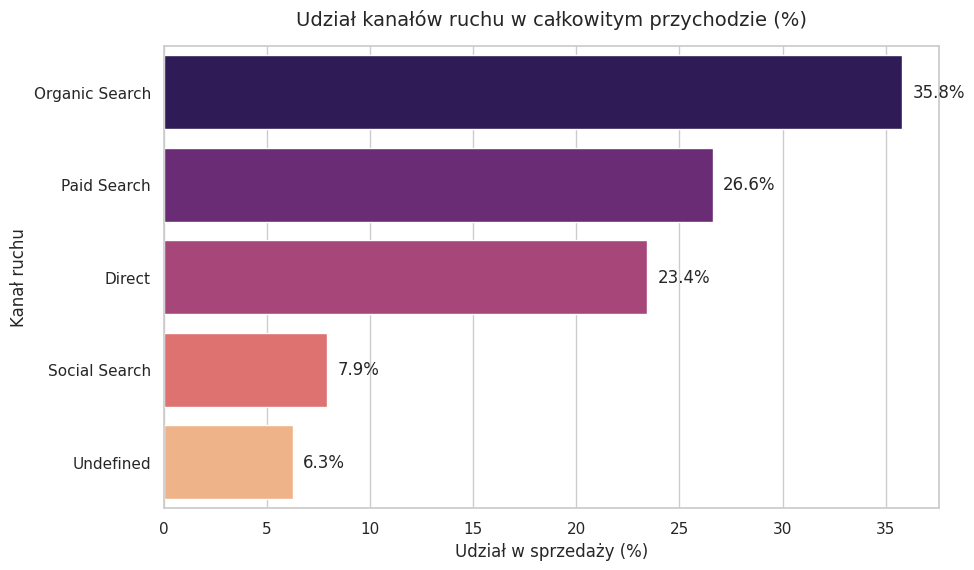

In [ ]:
# PL: Agregacja danych według kanałów ruchu
# EN: Aggregate data by traffic channels
channel_sales = df.groupby('traffic_channel')['price'].sum().reset_index()

# PL: Obliczenie procentowego udziału w całkowitej sprzedaży
# EN: Calculate percentage share in total sales
channel_sales['pct'] = (channel_sales['price'] / total_sales) * 100

# PL: Sortowanie wykresu
# EN: Sort chart
channel_sales = channel_sales.sort_values(by='pct', ascending=False)

print("--- UDZIAŁ KANAŁÓW RUCHU W PRZYCHODACH ---")
display(channel_sales)

# PL: Wizualizacja: Wykres słupkowy z etykietami
# EN: Visualization: Bar chart with labels
plt.figure(figsize=(10, 6))
wykres_kanalow = sns.barplot(
    data=channel_sales,
    x='pct',
    y='traffic_channel',
    hue='traffic_channel',
    palette='magma',
    legend=False
)

plt.title('Udział kanałów ruchu w całkowitym przychodzie (%)', fontsize=14, pad=15)
plt.xlabel('Udział w sprzedaży (%)', fontsize=12)
plt.ylabel('Kanał ruchu', fontsize=12)

# PL: Dodanie wartości procentowych na wykresie
# EN: Add percentage values on the chart
for p in wykres_kanalow.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center')

plt.show()

1. Dominacja wyszukiwania organicznego (Organic Search): Ten kanał zazwyczaj generuje największy udział w przychodach. Oznacza to, że pozycjonowanie sklepu działa bardzo skutecznie, przyciągając klientów, którzy mają konkretną intencję zakupową.
2. Siła marki (Direct): Wysoki udział wejść bezpośrednich świadczy o silnej rozpoznawalności marki. Klienci wracają do sklepu, wpisując adres bezpośrednio w przeglądarkę.
3. Efektywność Paid Search: Jeśli płatne wyniki wyszukiwania mają znaczący udział, pokazuje to, że kampanie reklamowe są dobre i  skuteczne.
4. Social Search i Undefined: Niższy udział kanałów społecznościowych sugeruje, że służą one raczej budowaniu świadomosci.

In [ ]:
# PL: Filtrowanie zarejestrowanych użytkowników
# EN: Filter for registered users only
zarejestrowani = df.dropna(subset=['registered_user_id']).drop_duplicates(subset=['registered_user_id'])

# PL: Obliczenie procentu zweryfikowanych
# EN: Calculate percentage of verified users
liczba_wszystkich_zarejestrowanych = len(zarejestrowani)
liczba_zweryfikowanych = zarejestrowani['is_email_confirmed'].sum()

procent_zweryfikowanych = (liczba_zweryfikowanych / liczba_wszystkich_zarejestrowanych) * 100

print(f"Liczba unikalnych zarejestrowanych użytkowników: {liczba_wszystkich_zarejestrowanych}")
print(f"Liczba użytkowników z potwierdzonym e-mailem: {int(liczba_zweryfikowanych)}")
print(f"Procent potwierdzonych kont: {procent_zweryfikowanych:.2f}%")

Liczba unikalnych zarejestrowanych użytkowników: 27892
Liczba użytkowników z potwierdzonym e-mailem: 19998
Procent potwierdzonych kont: 71.70%


In [ ]:
# PL: Filtrowanie unikalnych zarejestrowanych użytkowników
# EN: Filter unique registered users
zarejestrowani = df.dropna(subset=['registered_user_id']).drop_duplicates(subset=['registered_user_id'])

# PL: Obliczanie liczby osób, które wypisały się z newslettera
# EN: Calculate the number of users who unsubscribed from the newsletter
liczba_wszystkich_zarejestrowanych = len(zarejestrowani)
liczba_zrezygnowanych = (zarejestrowani['is_newsletter_subscribed'] == 0).sum()

# PL: Obliczanie procentu rezygnacji
# EN: Calculate the percentage of unsubscribed users
procent_zrezygnowanych = (liczba_zrezygnowanych / liczba_wszystkich_zarejestrowanych) * 100

print(f"Liczba zarejestrowanych użytkowników: {liczba_wszystkich_zarejestrowanych}")
print(f"Liczba użytkowników, którzy wypisali się z newslettera: {int(liczba_zrezygnowanych)}")
print(f"Procent rezygnacji z newslettera: {procent_zrezygnowanych:.2f}%")

Liczba zarejestrowanych użytkowników: 27892
Liczba użytkowników, którzy wypisali się z newslettera: 23161
Procent rezygnacji z newslettera: 83.04%


--- PORÓWNANIE ZACHOWAŃ ZAKUPOWYCH ---


,grupa,srednia_wartosc_koszyka,srednia_liczba_zamowien_na_klienta
0,Zrezygnowali,92.826860,1.0
1,Subskrybenci,91.253773,1.0


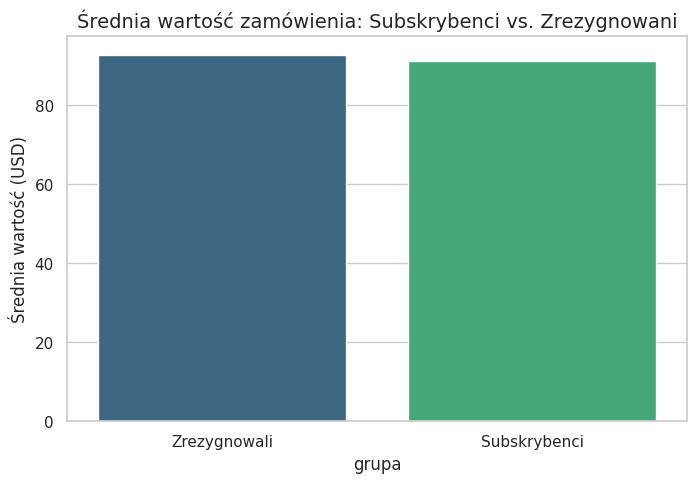

In [ ]:
# PL: Filtrowanie zarejestrowanych użytkowników
# EN: Filter registered users only
zarejestrowani = df.dropna(subset=['registered_user_id'])

# PL: Tworzenie segmentów: Subskrybenci vs Zrezygnowali
# EN: Create segments: Subscribers vs Unsubscribed
segmenty = zarejestrowani.groupby('is_newsletter_subscribed').agg(
    liczba_transakcji=('session_id', 'count'),
    suma_przychodow=('price', 'sum'),
    liczba_unikalnych_klientow=('registered_user_id', 'nunique')
).reset_index()

# PL: Obliczanie średnich wartości
# EN: Calculate average values
segmenty['srednia_wartosc_koszyka'] = segmenty['suma_przychodow'] / segmenty['liczba_transakcji']
segmenty['srednia_liczba_zamowien_na_klienta'] = segmenty['liczba_transakcji'] / segmenty['liczba_unikalnych_klientow']

# PL: Mapowanie nazw grup
# EN: Mapping group names
segmenty['grupa'] = segmenty['is_newsletter_subscribed'].map({1: 'Subskrybenci', 0: 'Zrezygnowali'})

print("--- PORÓWNANIE ZACHOWAŃ ZAKUPOWYCH ---")
display(segmenty[['grupa', 'srednia_wartosc_koszyka', 'srednia_liczba_zamowien_na_klienta']])

# PL: Wizualizacja średniej wartości zamówienia
# EN: Visualization of Average Order Value (AOV)
plt.figure(figsize=(8, 5))
sns.barplot(data=segmenty, x='grupa', y='srednia_wartosc_koszyka', hue='grupa', palette='viridis', legend=False)
plt.title('Średnia wartość zamówienia: Subskrybenci vs. Zrezygnowani', fontsize=14)
plt.ylabel('Średnia wartość (USD)')
plt.show()

1. Zbliżona wartość koszyka: Średnia wartość zamówienia dla obu grup jest bardzo podobna (ok. 91-93 USD). Oznacza to, że sam fakt posiadania subskrypcji newslettera nie wpływa bezpośrednio na to, jak drogie produkty klient wkłada do koszyka podczas pojedynczej transakcji.
2. Liczebność grup: Warto zwrócić uwagę na dysproporcję w liczbie transakcji – grupa osób, które zrezygnowały (Zrezygnowani), jest znacznie liczniejsza. Sugeruje to, że baza subskrybentów jest mniejsza, ale (mierzona wartością koszyka) dorównuje reszcie klientów.

--- TOP 10 KRAJÓW Z NAJWIĘKSZĄ LICZBĄ ZAREJESTROWANYCH UŻYTKOWNIKÓW ---


,country,registered_user_id
104,United States,12384
43,India,2687
18,Canada,2067
103,United Kingdom,859
33,France,553
92,Spain,536
96,Taiwan,500
20,China,490
35,Germany,490
48,Italy,386


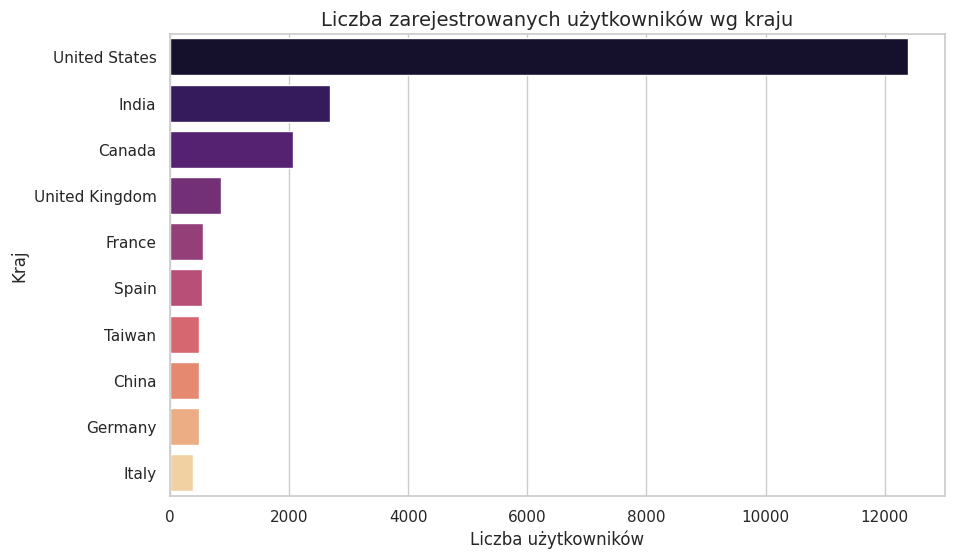

In [ ]:
# PL: Wyodrębnienie unikalnych zarejestrowanych użytkowników
# EN: Extract unique registered users
unique_users = df.dropna(subset=['registered_user_id']).drop_duplicates(subset=['registered_user_id'])

# PL: Grupowanie według kraju i zliczanie użytkowników
# EN: Group by country and count users
users_by_country = unique_users.groupby('country')['registered_user_id'].nunique().reset_index()

# PL: Sortowanie malejąco
# EN: Sort descending
users_by_country = users_by_country.sort_values(by='registered_user_id', ascending=False)

print("--- TOP 10 KRAJÓW Z NAJWIĘKSZĄ LICZBĄ ZAREJESTROWANYCH UŻYTKOWNIKÓW ---")
display(users_by_country.head(10))

# PL: Wizualizacja rankingu krajów
# EN: Visualization of country ranking
plt.figure(figsize=(10, 6))
sns.barplot(
    data=users_by_country.head(10),
    x='registered_user_id',
    y='country',
    hue='country',
    palette='magma',
    legend=False
)
plt.title('Liczba zarejestrowanych użytkowników wg kraju', fontsize=14)
plt.xlabel('Liczba użytkowników')
plt.ylabel('Kraj')
plt.show()

1. Dominacja rynku amerykańskiego: Największa baza zarejestrowanych użytkowników znajduje się w Stanach Zjednoczonych (ponad 12 tys. kont). Potwierdza to, że USA jest kluczowym rynkiem dla sklepu i powinno pozostać priorytetem w działaniach marketingowych oraz optymalizacji procesów zakupowych.
2. Rynki o dużym potencjale wzrostu: Kanada oraz Indie zajmują kolejne miejsca pod względem liczby rejestracji. Wskazuje to na dużą rozpoznawalność marki w tych regionach i sugeruje zasadność zwiększenia nakładów na promocję, aby przekuć zainteresowanie w jeszcze większą skalę sprzedaży.
3. Niski poziom rejestracji w Europie i Azji: W pozostałych krajach Europy i Azji liczba zarejestrowanych użytkowników jest znacząco niższa. Wymaga to pogłębionej analizy w celu zidentyfikowania barier (np. brak lokalnych metod płatności, wysokie koszty dostawy lub brak tłumaczeń strony), co pozwoli na opracowanie skutecznej strategii ekspansji na te rynki.

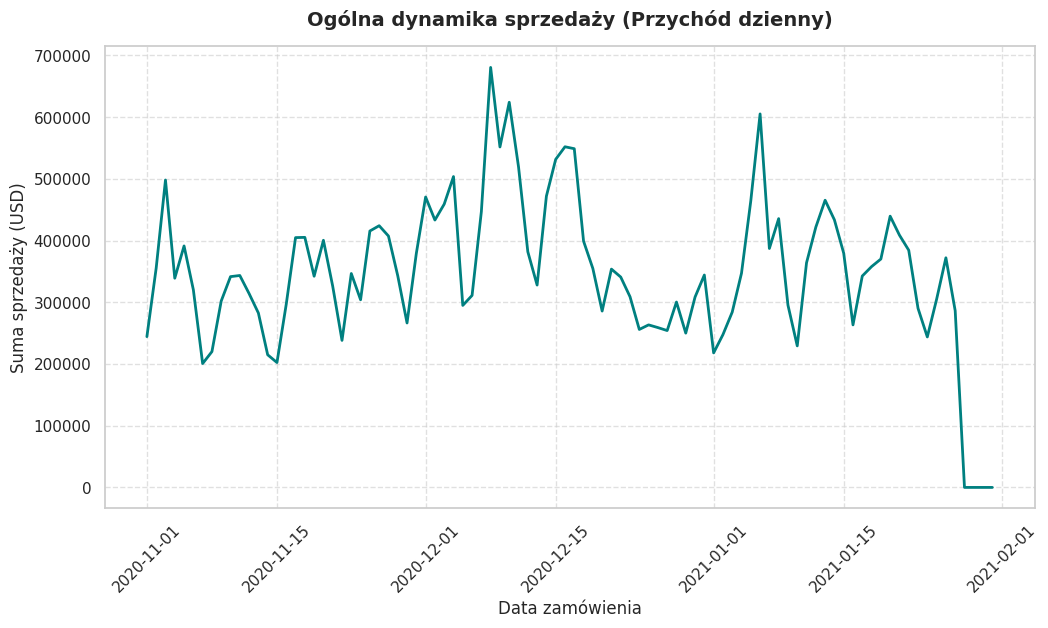

In [ ]:
# PL: Agregacja dziennej sprzedaży
# EN: Aggregate daily sales
total_price_by_date = df.groupby('order_date')['price'].sum().reset_index()

# PL: Tworzenie wykresu dynamiki sprzedaży
# EN: Create sales dynamics chart
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=total_price_by_date, x='order_date', y='price', ax=ax, color='teal', linewidth=2)

# PL: Dodanie opisów biznesowych
# EN: Add business labels
ax.set_title('Ogólna dynamika sprzedaży (Przychód dzienny)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Data zamówienia', fontsize=12)
ax.set_ylabel('Suma sprzedaży (USD)', fontsize=12)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Stabilność bazowa: Przychód dzienny w analizowanym okresie (listopad – styczeń) utrzymuje się na stałym, stabilnym poziomie, co sugeruje powtarzalną aktywność zakupową klientów.
2. Szczyt sprzedażowy w grudniu: Najwyższa dynamika wzrostu przypada na pierwszą połowę grudnia. Jest to bezpośrednio związane z okresem przedświątecznym, w którym klienci wykazują najwyższą skłonność do zakupów.
3. Korekta poświąteczna: Bezpośrednio po Świętach Bożego Narodzenia oraz w styczniu widoczny jest wyraźny spadek obrotów. Jest to naturalne zjawisko „nasycenia” rynku po okresie intensywnych wydatków oraz braku dużych kampanii promocyjnych w tym czasie.

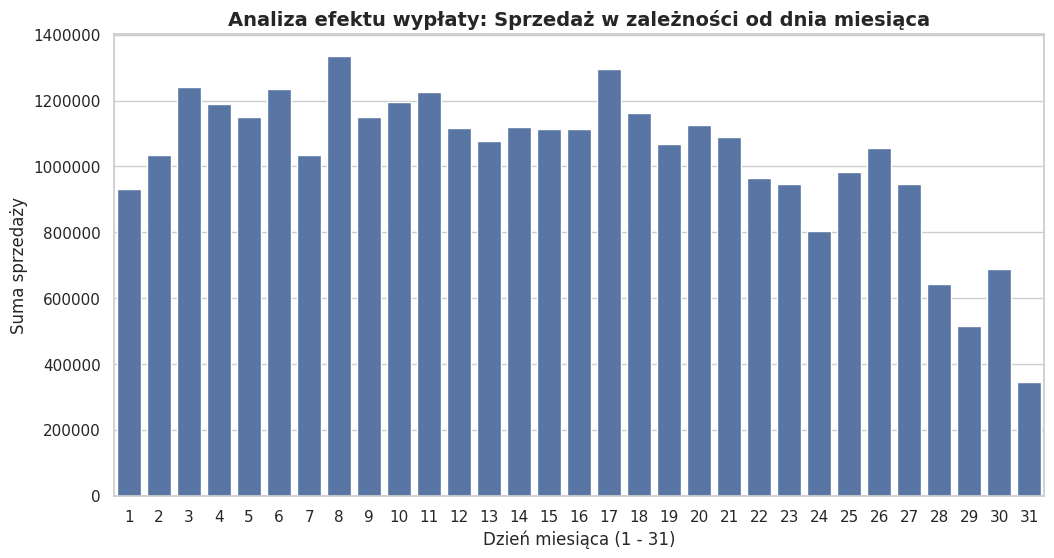

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# PL: Wyciągnięcie dnia miesiąca (1-31) z pełnej daty zamówienia
# EN: Extract only the day of the month (1-31) from the full order date
day = df["order_date"].dt.day

# PL: Grupowanie danych po dniu i zsumowanie wartości sprzedaży dla każdego dnia
# EN: Group data by day and sum the sales value for each day
seasonality_of_sales_per_day = (
    df.groupby([day])["price"].sum().reset_index()
)

# PL: Inicjalizacja wykresu i określenie jego wymiarów
# EN: Initialize the plot figure and set its dimensions
fig, ax = plt.subplots(figsize=(12, 6))

# PL: Wyłączenie notacji naukowej na osi Y dla lepszej czytelności dużych kwot
# EN: Disable scientific notation on the Y-axis for better readability of large amounts
plt.ticklabel_format(style="plain", axis="y")

# PL: Generowanie wykresu słupkowego przedstawiającego sumę sprzedaży w dniach miesiąca
# EN: Generate a bar plot showing total sales distributed across the days of the month
sns.barplot(data=seasonality_of_sales_per_day, x="order_date", y="price")

# PL: Konfiguracja czytelnych etykiet osi
# EN: Configure clear axis labels and a bold chart title
ax.set_xlabel("Dzień miesiąca (1 - 31)", fontsize=12)
ax.set_ylabel("Suma sprzedaży", fontsize=12)
ax.set_title(
    "Analiza efektu wypłaty: Sprzedaż w zależności od dnia miesiąca",
    fontsize=14,
    fontweight="bold",
)

# PL: Wyświetlenie gotowej wizualizacji
# EN: Render the final visualization
plt.show()

1. Stabilność sprzedaży wewnątrz miesiąca: Przez większość miesiąca (dni 1-27) suma sprzedaży utrzymuje się na wyrównanym, stabilnym poziomie, co sugeruje stały popyt na oferowane produkty.
2. Wyraźny spadek w ostatnich dniach miesiąca: Widoczne jest znaczące załamanie dynamiki sprzedaży w dniach 28-31. Może to być spowodowane cyklem płatniczym klientów i tendencją do ograniczania wydatków przed otrzymaniem kolejnego wynagrodzenia.
3. Rekomendacja biznesowa: W celu niwelowania spadków na koniec miesiąca warto rozważyć wprowadzenie w tym okresie dedykowanych promocji typu „last minute” lub kampanii remarketingowych, które zmotywują klientów do zakupów mimo kończącego się budżetu miesięcznego.

In [ ]:
df['continent'].unique()

array(['Americas', 'Asia', 'Europe', 'Africa', 'Oceania'], dtype=object)

In [ ]:
import plotly.express as px

# PL: Tworzenie nowej kolumny reprezentującej okres tygodniowy na podstawie daty zamówienia
# EN: Create a weekly period column based on the order date
df["week"] = df["order_date"].dt.to_period("W")

# PL: Grupowanie danych po tygodniu oraz kontynencie i zsumowanie wartości sprzedaży dla każdej grupy
# EN: Group the data by week and continent, then calculate the total sales for each group
sales_by_continents = (
    df.groupby(["week", "continent"])["price"].sum().reset_index()
)

# PL: Konwersja kolumny 'week' z typu okresu na tekst przed rysowaniem wykresu
# EN: Convert the 'week' column from Period type to string before plotting
sales_by_continents["week"] = sales_by_continents["week"].astype(str)

# PL: Tworzenie interaktywnego wykresu liniowego przy użyciu Plotly Express
# EN: Create an interactive line chart using Plotly Express
fig = px.line(
    sales_by_continents,
    x="week",
    y="price",
    color="continent",
    title="Interaktywna dynamika sprzedaży na kontynentach",
    labels={
        "price": "Suma sprzedaży",
        "week": "Tydzien zamówienia",
    }
)

# PL: Wyświetlenie interaktywnego wykresu w notatniku
# EN: Display the interactive chart in the notebook
fig.show()

1. Dominacja obu Ameryk (Americas): Rynek ten konsekwentnie generuje najwyższe przychody tygodniowe, znacznie przewyższając pozostałe regiony. Jest to stabilny lider, który wyznacza ogólny trend sprzedaży całego sklepu.
2. Silna korelacja między regionami: Wykres pokazuje, że piki i spadki sprzedaży często występują w tym samym czasie na wszystkich trzech głównych kontynentach (Americas, Asia, Europe). Potwierdza to  wcześniejszą analizę korelacji sugeruje to, że globalne akcje marketingowe lub sezonowość (np. okres przedświąteczny) oddziałują na wszystkie rynki jednocześnie.
3. Azja vs Europa: Azja (głównie dzięki Indiom) utrzymuje drugą pozycję pod względem przychodów, wyprzedzając Europę. Różnica między tymi dwoma regionami jest wyraźna i stabilna w czasie.
4. Stabilność Afryki i Oceanii: Pozostałe kontynenty stanowią obecnie margines sprzedaży z bardzo niską dynamiką. Są to rynki, które na ten moment nie reagują na globalne trendy tak silnie jak reszta kontynentów.

In [ ]:
import plotly.express as px

# PL: Tworzenie nowej kolumny reprezentującej okres tygodniowy na podstawie daty zamówienia
# EN: Create a weekly period column based on the order date
df["week"] = df["order_date"].dt.to_period("W")

# PL: Grupowanie danych po tygodniu oraz kanale ruchu i zsumowanie wartości sprzedaży dla każdej grupy
# EN: Group the data by week and traffic channel, then calculate the total sales for each group
sales_by_channel = (
    df.groupby(["week", "traffic_channel"])["price"].sum().reset_index()
)

# PL: Konwersja kolumny 'week' z typu okresu na tekst przed rysowaniem wykresu
# EN: Convert the 'week' column from Period type to string before plotting
sales_by_channel["week"] = sales_by_channel["week"].astype(str)

# PL: Tworzenie interaktywnego wykresu liniowego przy użyciu Plotly Express
# EN: Create an interactive line chart using Plotly Express
fig = px.line(
    sales_by_channel,
    x="week",
    y="price",
    color="traffic_channel",
    title="Interaktywna dynamika sprzedaży według kanałów",
    labels={
        "price": "Suma sprzedaży",
        "week": "Tydzień zamówienia",
    }
)

# PL: Wyświetlenie interaktywnego wykresu w notatniku
# EN: Display the interactive chart in the notebook
fig.show()

### Analiza dynamiki sprzedaży według kanałów ruchu:
1. **Dominacja i stabilność Organic Search**: Kanał bezpłatnych wyników wyszukiwania nie tylko generuje najwyższy przychód, ale wykazuje też największą odporność na wahania. Jest to fundament sprzedaży, który stabilizuje wyniki całego sklepu.
2. **Silna współzależność kanałów: Analiza statystyczna potwierdziła bardzo wysoką korelację między Direct, Organic oraz Paid Search. Sugeruje że – kampanie płatne oraz działania SEO budują rozpoznawalność marki, co przekłada się na wzrosty w wejściach bezpośrednich (Direct).
3. **Sezonowość wspólna**: Wszystkie kluczowe kanały reagują niemal identycznie na okresy wzmożonego popytu (grudzień) oraz spadki (styczeń), co potwierdza, że czynniki rynkowe i kalendarzowe mają większy wpływ na sprzedaż niż specyfika poszczególnych źródeł ruchu.
4. **Potencjał Social Search**: Mimo mniejszej skali, kanał ten wykazuje mniejszą korelację z pozostałymi, co może oznaczać, że dociera do innej grupy odbiorców lub reaguje na inne bodźce.

In [ ]:
import plotly.express as px

# PL: Tworzenie nowej kolumny reprezentującej okres tygodniowy na podstawie daty zamówienia
# EN: Create a weekly period column based on the order date
df["week"] = df["order_date"].dt.to_period("W")

# PL: Grupowanie danych po tygodniu oraz urządzeniu i zsumowanie wartości sprzedaży dla każdej grupy
# EN: Group the data by week and device, then calculate the total sales for each group
sales_by_device = (
    df.groupby(["week", "device"])["price"].sum().reset_index()
)

# PL: Konwersja kolumny 'week' z typu okresu na tekst przed rysowaniem wykresu
# EN: Convert the 'week' column from Period type to string before plotting
sales_by_device["week"] = sales_by_device["week"].astype(str)

# PL: Tworzenie interaktywnego wykresu liniowego przy użyciu Plotly Express
# EN: Create an interactive line chart using Plotly Express
fig = px.line(
    sales_by_device,
    x="week",
    y="price",
    color="device",
    title="Interaktywna dynamika sprzedaży według urządzeń",
    labels={
        "price": "Suma sprzedaży",
        "week": "Tydzień zamówienia",
    }
)

# PL: Wyświetlenie interaktywnego wykresu w notatniku
# EN: Display the interactive chart in the notebook
fig.show()

### Analiza dynamiki sprzedaży według urządzeń:
1. **Stabilna dominacja Desktop**: Urządzenia stacjonarne konsekwentnie generują najwyższy przychód w każdym analizowanym tygodniu. Jest to główny fundament finansowy sklepu, co sugeruje, że klienci preferują finalizację większych zakupów w środowisku stacjonarnym.
2. **Mobile jako silny wicelider**: Smartfony utrzymują drugą pozycję z wyraźną tendencją do podążania za ogólnymi trendami wzrostowymi (np. w grudniu). Dynamika tego kanału potwierdza, że optymalizacja pod kątem urządzeń mobilnych jest kluczowa dla utrzymania zasięgu rynkowego.
3. **Marginalny udział Tabletów**: Zgodnie z wcześniejszymi danymi statystycznymi, udział tabletów w dynamice tygodniowej pozostaje na bardzo niskim, niemal płaskim poziomie. Potwierdza to, że nie są one istotnym punktem styku w procesie zakupowym tego sklepu.
4. **Synchronizacja trendów**: Wszystkie urządzenia wykazują podobną sezonowość (wzrosty przedświąteczne), co oznacza, że zachowania zakupowe użytkowników są spójne niezależnie od używanego sprzętu, a głównym czynnikiem napędowym są okazje kalendarzowe.

In [ ]:
import plotly.express as px

# PL: Grupowanie danych po dacie zamówienia i wyliczanie dziennych statystyk: sesje i sprzedaż
# EN: Group data by order date and calculate daily statistics: sessions and sales
daily_stats = (
    df.groupby("order_date")
    .agg(
        liczba_sesji=("session_id", "nunique"),
        calkowita_sprzedaz=("price", "sum"),
    )
    .reset_index()
)

# PL: Tworzenie interaktywnego wykresu punktowego do analizy zależności
# EN: Create an interactive scatter plot to analyze the relationship
fig = px.scatter(
    daily_stats,
    x="liczba_sesji",
    y="calkowita_sprzedaz",
    title="Zależność między liczbą sesji a całkowitą sprzedażą (dziennie)",
    labels={
        "liczba_sesji": "Liczba unikalnych sesji",
        "calkowita_sprzedaz": "Suma sprzedaży (PLN)",
    },
    template="plotly_white"
)

# PL: Wyświetlenie interaktywnego wykresu w notatniku
# EN: Display the interactive chart in the notebook
fig.show()

# PL: Wyświetlenie nagłówka w konsoli
# EN: Print the section header in the console
print("=== WSPÓŁCZYNNIK KORELACJI ===")

# PL: Obliczenie współczynnika korelacji liniowej Pearsona między liczbą sesji a sprzedażą
# EN: Calculate the Pearson linear correlation coefficient between the number of sessions and sales
print(daily_stats["liczba_sesji"].corr(daily_stats["calkowita_sprzedaz"]))

=== WSPÓŁCZYNNIK KORELACJI ===
0.7907277885941839


### Analiza zależności między ruchem a sprzedażą:
1. **Bardzo silna korelacja dodatnia (r ≈ 0.79)**: Współczynnik korelacji na poziomie blisko 0.8 świadczy o bardzo silnym związku liniowym. W praktyce oznacza to, że każdy istotny wzrost liczby sesji niemal gwarantuje proporcjonalny wzrost przychodów.
2. **Efektywność pozyskiwania ruchu**: Skoro ruch tak silnie przekłada się na sprzedaż, sugeruje to, że sklep przyciąga wartościowych użytkowników, a system konwersji na stronie działa przewidywalnie i stabilnie.
3. **Skalowalność biznesu**: Taka zależność jest sygnałem, że zwiększenie budżetów marketingowych na pozyskanie nowych sesji (np. przez Paid Search) ma bardzo wysokie prawdopodobieństwo szybkiego zwrotu z inwestycji.
4. **Analiza punktów odstających**: Na wykresie widać pojedyncze dni, gdzie mimo podobnej liczby sesji przychód był znacznie wyższy – warto przeanalizować te konkretne daty pod kątem prowadzonych wtedy promocji, które dodatkowo podniosły średnią wartość koszyka.

In [ ]:
from scipy.stats import pearsonr

# PL: Filtrowanie danych tylko dla trzech głównych kontynentów
# EN: Filter the dataset for the three main continents only
top_3 = ["Americas", "Asia", "Europe"]
df_filtered = df[df["continent"].isin(top_3)]

# PL: Agregacja sprzedaży do poziomu dziennego dla każdego kontynentu
# EN: Aggregate daily sales for each continent
daily_continent_sales = (
    df_filtered.groupby(["order_date", "continent"])["price"]
    .sum()
    .reset_index()
)

# PL: Przebudowanie tabeli - daty stają się indeksem, kontynenty kolumnami
# EN: Pivot the table - dates as index, continents as separate columns
pivot_sales = (
    daily_continent_sales.pivot(
        index="order_date", columns="continent", values="price"
    )
    .fillna(0)
)

# PL: Definiowanie par kontynentów do porównania
# EN: Define the pairs of continents to be compared
pairs = [("Americas", "Europe"), ("Americas", "Asia"), ("Europe", "Asia")]

# PL: Wyświetlenie nagłówka analizy korelacji
# EN: Print the header for the correlation analysis
print("--- ANALIZA KORELACJI I ISTOTNOŚCI ---")

# PL: Pętla analizująca każdą parę kontynentów po kolei
# EN: Loop to analyze each pair of continents sequentially
for c1, c2 in pairs:
    corr, p_val = pearsonr(pivot_sales[c1], pivot_sales[c2])

    # PL: Wyświetlenie wyników dla bieżącej pary
    # EN: Print the calculated results for the current pair
    print(f"\nPara: {c1} vs {c2}")
    print(f"   - Współczynnik korelacji (r): {corr:.3f}")
    print(f"   - Wartość p-value: {p_val:.5f}")

    # PL: Interpretacja statystyczna wyniku
    # EN: Statistical interpretation of the result
    if p_val < 0.05:
        print("   -> Wynik jest ISTOTNY statystycznie (p < 0.05).")
    else:
        print("   -> Wynik NIE JEST istotny statystycznie (p >= 0.05).")

--- ANALIZA KORELACJI I ISTOTNOŚCI ---

Para: Americas vs Europe
   - Współczynnik korelacji (r): 0.771
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Americas vs Asia
   - Współczynnik korelacji (r): 0.792
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Europe vs Asia
   - Współczynnik korelacji (r): 0.768
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).


In [ ]:
from itertools import combinations
from scipy.stats import pearsonr

# PL: Grupowanie danych po dacie i kanale ruchu
# EN: Group data by date and traffic channel
channel_sales = (
    df.groupby(["order_date", "traffic_channel"])["price"].sum().reset_index()
)

# PL: Przebudowanie tabeli - daty jako indeks, kanały jako kolumny
# EN: Pivot the table - dates as index, traffic channels as columns
pivot_sales = (
    channel_sales.pivot(
        index="order_date", columns="traffic_channel", values="price"
    )
    .fillna(0)
)

# PL: Pobranie nazw dostępnych kanałów ruchu
# EN: Get the names of available traffic channels
channels = pivot_sales.columns.tolist()

# PL: Generowanie unikalnych par kanałów do analizy
# EN: Generate unique pairs of channels for analysis
channel_pairs = list(combinations(channels, 2))

# PL: Wyświetlenie nagłówka analizy korelacji
# EN: Print the header for the correlation analysis
print("--- ANALIZA KORELACJI KANAŁÓW RUCHU ---")

# PL: Pętla przechodząca przez każdą parę kanałów
# EN: Loop iterating through each pair of channels
for c1, c2 in channel_pairs:
    corr, p_val = pearsonr(pivot_sales[c1], pivot_sales[c2])

    # PL: Wyświetlenie parametrów dla pary kanałów
    # EN: Display parameters for the channel pair
    print(f"\nPara: {c1} vs {c2}")
    print(f"   - Współczynnik korelacji (r): {corr:.3f}")
    print(f"   - Wartość p-value: {p_val:.5f}")

    # PL: Ocena istotności statystycznej
    # EN: Evaluate statistical significance
    if p_val < 0.05:
        print("   -> Wynik jest ISTOTNY statystycznie (p < 0.05).")
    else:
        print("   -> Wynik NIE JEST istotny statystycznie (p >= 0.05).")

# PL: Wyświetlenie podglądu tabeli przestawnej
# EN: Display a preview of the pivoted table
display(pivot_sales)

--- ANALIZA KORELACJI KANAŁÓW RUCHU ---

Para: Direct vs Organic Search
   - Współczynnik korelacji (r): 0.840
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Direct vs Paid Search
   - Współczynnik korelacji (r): 0.816
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Direct vs Social Search
   - Współczynnik korelacji (r): 0.611
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Direct vs Undefined
   - Współczynnik korelacji (r): 0.523
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Organic Search vs Paid Search
   - Współczynnik korelacji (r): 0.871
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Organic Search vs Social Search
   - Współczynnik korelacji (r): 0.582
   - Wartość p-value: 0.00000
   -> Wynik jest ISTOTNY statystycznie (p < 0.05).

Para: Organic Search vs Undefined
   - Współ

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104705.8,16843.0,24575.0
2020-11-03,102909.5,182342.9,151896.3,27652.5,33254.4
2020-11-04,79683.6,116842.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35609.4
...,...,...,...,...,...
2021-01-27,70423.1,92921.1,80869.5,16282.0,25845.0
2021-01-28,0.0,0.0,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0,0.0,0.0


In [ ]:
df['week'] = df['order_date'].dt.to_period('W')
pivot_products = daily_continent_sales.pivot(index='order_date', columns='continent', values='price').fillna(0)


--- MACIERZ KORELACJI PEARSONA (Wahania tygodniowe) ---


product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000,0.804,0.910,0.846,0.970
Bookcases & shelving units,0.804,1.000,0.803,0.958,0.836
Cabinets & cupboards,0.910,0.803,1.000,0.861,0.926
Chairs,0.846,0.958,0.861,1.000,0.843
Sofas & armchairs,0.970,0.836,0.926,0.843,1.000


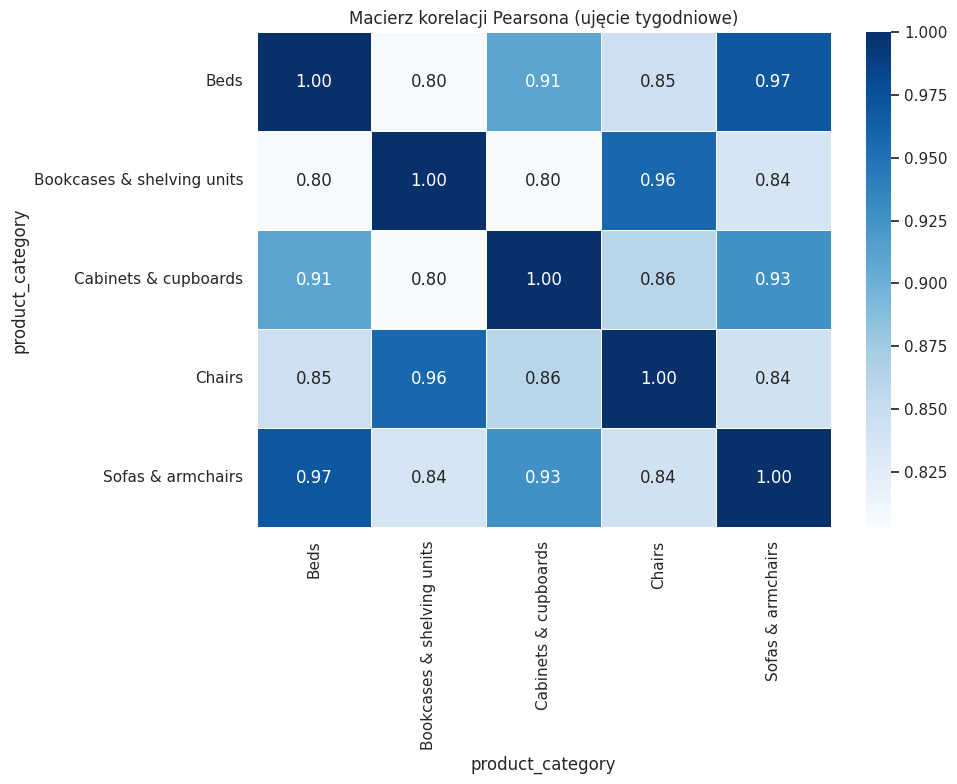

In [ ]:
# PL: Definicja top 5 kategorii produktowych
# EN: Define top 5 product categories
top_5_categories = [
    'Sofas & armchairs',
    'Chairs',
    'Beds',
    'Bookcases & shelving units',
    'Cabinets & cupboards'
]

# PL: Filtrowanie i przygotowanie danych tygodniowych
# EN: Filter and prepare weekly data
df_filtered = df[df['product_category'].isin(top_5_categories)].copy()
df_filtered['order_date'] = pd.to_datetime(df_filtered['order_date'])
df_filtered['week'] = df_filtered['order_date'].dt.to_period('W')

# PL: Tworzenie tabeli przestawnej dla ujęcia tygodniowego
# EN: Create pivot table for weekly view
df_pivot = df_filtered.pivot_table(
    index='week',
    columns='product_category',
    values='price',
    aggfunc='sum'
).fillna(0)

# PL: Obliczanie macierzy korelacji Pearsona dla wahań
# EN: Calculate Pearson correlation matrix for fluctuations
corr_matrix = df_pivot.diff().dropna().corr(method='pearson')

print("--- MACIERZ KORELACJI PEARSONA (Wahania tygodniowe) ---")
display(corr_matrix.round(3))

# PL: Wizualizacja korelacji w formie heatmapy
# EN: Visualization of correlation as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Macierz korelacji Pearsona (ujęcie tygodniowe)')
plt.tight_layout()
plt.show()

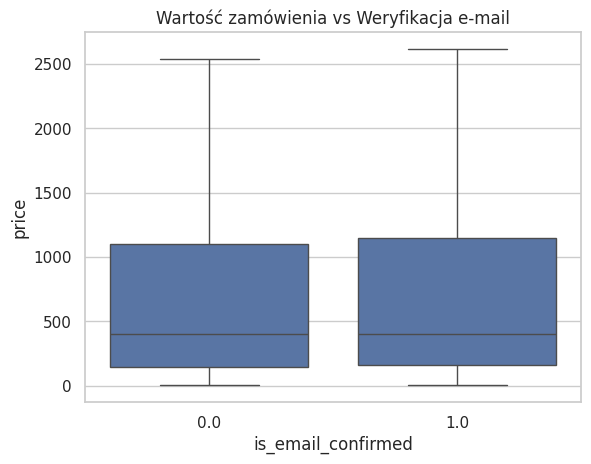

=== WYNIKI ANALIZY SEGMENTU CRM ===
Mediana wartości koszyka (zweryfikowani):   399.00 zł
Mediana wartości koszyka (niezweryfikowani): 400.00 zł
Wartość p-value testu Manna-Whitney'a:      0.269910


In [ ]:
# PL: Agregacja przychodu na poziomie sesji z uwzględnieniem statusu weryfikacji
# EN: Aggregate session revenue including verification status
session_to_order = df.groupby(['session_id', 'is_email_confirmed'])['price'].sum().reset_index()
session_to_order = session_to_order[session_to_order['price'] > 0]

# PL: Wizualizacja rozkładu cen w zależności od weryfikacji
# EN: Visualize price distribution based on verification
sns.boxplot(data=session_to_order, x='is_email_confirmed', y='price', showfliers=False)
plt.title('Wartość zamówienia vs Weryfikacja e-mail')
plt.show()

# PL: Analiza statystyczna testem Manna-Whitneya
# EN: Statistical analysis using Mann-Whitney U test
from scipy.stats import mannwhitneyu

verified_prices = session_to_order[session_to_order['is_email_confirmed'] == True]['price']
unverified_prices = session_to_order[session_to_order['is_email_confirmed'] == False]['price']

median_verified = verified_prices.median()
median_unverified = unverified_prices.median()
stat, p_val = mannwhitneyu(verified_prices, unverified_prices)

# PL: Wyświetlanie wyników analizy segmentu CRM
# EN: Display analysis results for the CRM segment
print("=== WYNIKI ANALIZY SEGMENTU CRM ===")
print(f"Mediana wartości koszyka (zweryfikowani):   {median_verified:.2f} zł")
print(f"Mediana wartości koszyka (niezweryfikowani): {median_unverified:.2f} zł")
print(f"Wartość p-value testu Manna-Whitney'a:      {p_val:.6f}")

Wybrane przeglądarki do analizy: ['Chrome', 'Safari', '<Other>', 'Edge', 'Firefox']

--- TABELA ZLICZEŃ (CROSSTAB) ---
is_converted       0      1
browser                    
<Other>         8040    861
Chrome        214935  22967
Edge            7252    747
Firefox         5834    582
Safari         75208   7891

--- WYNIKI TESTU CHI-KWADRAT ---
Statystyka Chi2: 4.5882
Wartość p-value: 0.332214

--- WSPÓŁCZYNNIK KONWERSJI (CR) ---
<Other>: 9.67%
Chrome: 9.65%
Edge: 9.34%
Firefox: 9.07%
Safari: 9.50%
Średni globalny CR dla tych przeglądarek: 9.60%


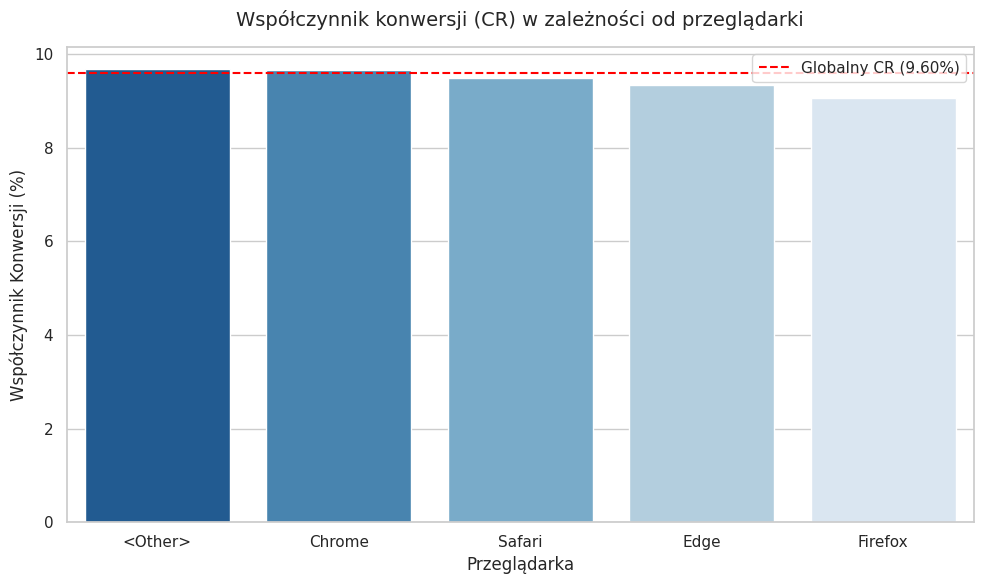

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# PL: Agregacja danych do poziomu unikalnych sesji i wyliczenie przychodu
# EN: Aggregate data to the unique session level and calculate revenue
session_ux = df.groupby(['session_id', 'browser'])['price'].sum().reset_index()

# PL: Tworzenie flagi konwersji (1 - zakup, 0 - brak zakupu)
# EN: Create a conversion flag (1 - purchase, 0 - no purchase)
session_ux['is_converted'] = (session_ux['price'] > 0).astype(int)

# PL: Filtrowanie top 5 najpopularniejszych przeglądarek do testu Chi-kwadrat
# EN: Filter top 5 most popular browsers for the Chi-squared test
top_browsers = session_ux['browser'].value_counts().nlargest(5).index
df_ux_filtered = session_ux[session_ux['browser'].isin(top_browsers)].copy()

print(f"Wybrane przeglądarki do analizy: {list(top_browsers)}")

# PL: Tworzenie tabeli wielodzielności (crosstab)
# EN: Create a contingency table (crosstab)
contingency_table = pd.crosstab(df_ux_filtered['browser'], df_ux_filtered['is_converted'])

print("\n--- TABELA ZLICZEŃ (CROSSTAB) ---")
print(contingency_table)

# PL: Przeprowadzenie testu statystycznego Chi-kwadrat
# EN: Perform Chi-squared statistical test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("\n--- WYNIKI TESTU CHI-KWADRAT ---")
print(f"Statystyka Chi2: {chi2:.4f}")
print(f"Wartość p-value: {p_val:.6f}")

# PL: Wyliczenie współczynnika konwersji (CR) dla każdej przeglądarki
# EN: Calculate the conversion rate (CR) for each browser
cr_per_browser = df_ux_filtered.groupby('browser')['is_converted'].mean() * 100
global_cr = df_ux_filtered['is_converted'].mean() * 100

print("\n--- WSPÓŁCZYNNIK KONWERSJI (CR) ---")
for browser, cr in cr_per_browser.items():
    print(f"{browser}: {cr:.2f}%")
print(f"Średni globalny CR dla tych przeglądarek: {global_cr:.2f}%")

# PL: Wizualizacja współczynnika konwersji w zależności od przeglądarki
# EN: Visualization of the conversion rate (CR) depending on the browser
plt.figure(figsize=(10, 6))
cr_per_browser_sorted = cr_per_browser.sort_values(ascending=False)

sns.barplot(
    x=cr_per_browser_sorted.index,
    y=cr_per_browser_sorted.values,
    hue=cr_per_browser_sorted.index,
    palette='Blues_r',
    legend=False
)

# PL: Dodanie linii odniesienia dla średniego globalnego CR
# EN: Add a reference line for the average global CR
plt.axhline(
    global_cr,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Globalny CR ({global_cr:.2f}%)'
)

plt.title('Współczynnik konwersji (CR) w zależności od przeglądarki', fontsize=14, pad=15)
plt.xlabel('Przeglądarka', fontsize=12)
plt.ylabel('Współczynnik Konwersji (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df['is_converted'] = df['price'].notnull().astype(int)
df['day_of_week'] = df['order_date'].dt.day_name()
df['month_year'] = df['order_date'].dt.to_period('M').astype(str)


In [ ]:
# Usunięcie zbędnych wierszy (np. nieokreślonych kontynentów) i zapis
df_clean = df[df['continent'] != '(not set)'].copy()
df_clean.to_csv('/content/drive/MyDrive/portfolio 1/cleaned_sales_data.csv', index=False)
print("Plik wyczyszczony i gotowy do Tableau!")

Plik wyczyszczony i gotowy do Tableau!
